# <b><font color='coral'>Предварительная обработка и очистка данных в Pandas</font></b>

### <font color='coral'>1. Масштабирование числовых характеристик (MinMaxScaler, StandardScaler)</font>
Включает в себя преобразование числовых столбцов к общему масштабу, что может улучшить производительность определенных алгоритмов и моделей. Pandas не предоставляет методов масштабирования напрямую, но вы можете использовать методы масштабирования из таких библиотек, как scikit-learn.

In [2]:
!pip install scikit-learn

##### <font color='coral'>1.1. Масштабирование по Мин-Максу (MinMaxScaler)</font>
Min-Max Scaling, также известная как нормализация, масштабирует числовые характеристики к заданному диапазону, обычно от 0 до 1. <br>
<b>Синтаксис</b>: MinMaxScaler(feature_range=(min, max))<br>
Параметры:  
- feature_range: кортеж (min, max), по умолчанию=(0, 1). Желаемый диапазон преобразованных данных

In [3]:
# Создание DataFrame
import pandas as pd
data = pd.DataFrame({
    'Feature1': [10, 20, 30, 40, 50],
    'Feature2': [0.1, 0.2, 0.3, 0.4, 0.5]
})
data

,Feature1,Feature2
0,10,0.1
1,20,0.2
2,30,0.3
3,40,0.4
4,50,0.5


In [5]:
# Импорт библиотеки
from sklearn.preprocessing import MinMaxScaler

In [6]:
# Min-Max Scaling
min_max_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data_min_max = min_max_scaler.fit_transform(data)
scaled_data_min_max

array([[0.  , 0.  ],
       [0.25, 0.25],
       [0.5 , 0.5 ],
       [0.75, 0.75],
       [1.  , 1.  ]])

##### <font color='coral'>1.2. Стандартное масштабирование (StandardScaler)</font>
Стандартное масштабирование, масштабирует числовые признаки так, чтобы их среднее значение было равно 0, а стандартное отклонение - 1.<br>

In [7]:
# Импорт библиотеки
from sklearn.preprocessing import StandardScaler

In [8]:
# Стандартное масштабирование
standard_scaler = StandardScaler()
scaled_data_standard = standard_scaler.fit_transform(data)
scaled_data_standard

array([[-1.41421356, -1.41421356],
       [-0.70710678, -0.70710678],
       [ 0.        ,  0.        ],
       [ 0.70710678,  0.70710678],
       [ 1.41421356,  1.41421356]])

Вывод:
- Стандартное масштабирование = про «относительность» (отклонение от среднего, поиск выбросов, корреляции).
- Минмакс масштабирование = про «нормализацию» (сравнение в процентах, визуализация, рейтинги).

### <font color='coral'>2. Выявление выбросов с помощью визуализации и статистических методов</font>

##### <font color='coral'>2.1. Методы визуализации</font>

###### <font color='coral'>2.1.1. Boxlpot</font>
Boxplot визуализирует распределение числовых данных по квартилям, выделяя все точки данных, которые находятся за пределами усов (т. е. потенциальные выбросы).

In [9]:
import matplotlib.pyplot as plt

In [10]:
# Образец DataFrame с числовыми характеристиками
df = pd.DataFrame({
    'NumericColumn': [10, 20, 30, 40, 50, 200],
    'NumericColumn1': [1, 2, 3, 4, 5, 100],
    'NumericColumn2': [0.1, 0.2, 0.3, 0.4, 0.5, 10]
})
df

,NumericColumn,NumericColumn1,NumericColumn2
0,10,1,0.1
1,20,2,0.2
2,30,3,0.3
3,40,4,0.4
4,50,5,0.5
5,200,100,10.0


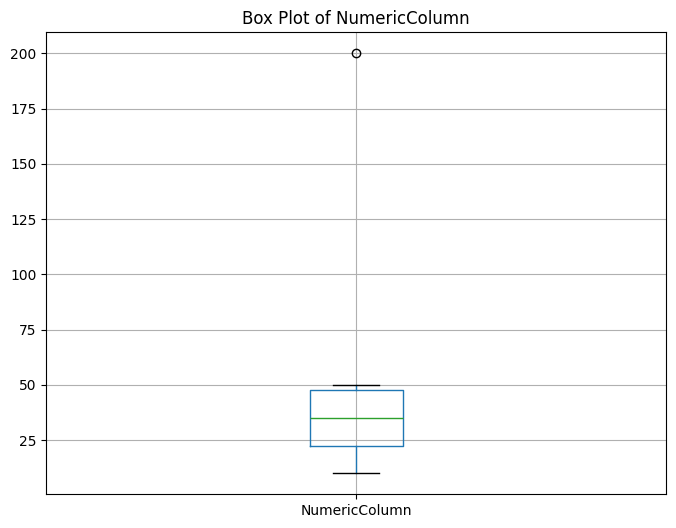

In [11]:
plt.figure(figsize=(8, 6))
df.boxplot(column='NumericColumn')
plt.title('Box Plot of NumericColumn')
plt.show()

###### <font color='coral'>2.1.2. Диаграмма рассеяния (scatterplot)</font>
Диаграмма рассеяния визуализирует связь между двумя числовыми переменными, позволяя заметить точки данных, которые значительно отклоняются от общей тенденции.

<Axes: xlabel='NumericColumn1', ylabel='NumericColumn2'>

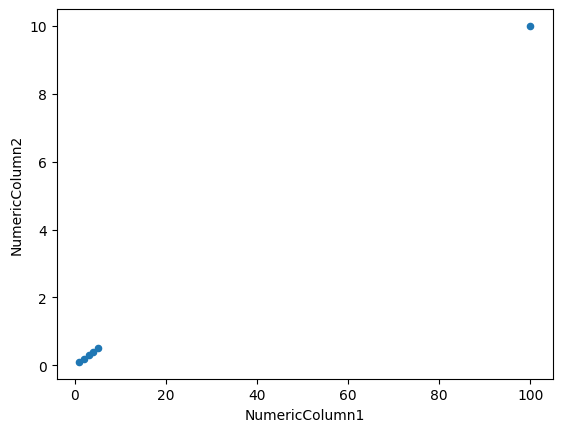

In [12]:
df.plot(kind = 'scatter', x = 'NumericColumn1', y = 'NumericColumn2')

##### <font color='coral'>2.2. Статистические методы</font>

###### <font color='coral'>2.2.1. Метод z-score</font>
Z-score измеряет, на сколько стандартных отклонений точка данных отклоняется от среднего значения набора данных. Как правило, точки данных с z-коэффициентом, превышающим определенный порог (например, 3 или -3), считаются выброшенными.

<b> Синтаксис:</b> scipy.stats.zscore(data, axis=0)<br>
Параметры:
- data - массив. Входные данные.
- axis - int или None, по умолчанию 0. Ось, вдоль которой вычисляются z-score. Если None, то вычисление производится по всему массиву.

Возвращает: Массив z-баллов для каждой точки данных.

In [13]:
import scipy.stats

In [14]:
z_scores = scipy.stats.zscore(df['NumericColumn'])
print("Z-Scores для NumericColumn:")
print(z_scores)

Z-Scores для NumericColumn:
[-0.74753193 -0.59287015 -0.43820837 -0.28354659 -0.12888482  2.19104186]


In [15]:
type(scipy.stats.zscore(df['NumericColumn']))

numpy.ndarray

###### <font color='coral'>2.2.2. Метод IQR</font>
Межквартильный интервал (IQR) измеряет разброс средних 50% данных. Выбросы обычно определяются как точки данных, которые находятся ниже Q1 - 1,5 * IQR или выше Q3 + 1,5 * IQR.

In [16]:
Q1 = df['NumericColumn'].quantile(0.25)
Q3 = df['NumericColumn'].quantile(0.75)
IQR = Q3 - Q1
df[(df['NumericColumn'] < Q1 - 1.5 * IQR) | (df['NumericColumn'] > Q3 + 1.5 * IQR)]['NumericColumn']

5    200
Name: NumericColumn, dtype: int64

### <font color='coral'>3. Обработка выбросов (удаление, усечение, преобразование)</font>

##### <font color='coral'>3.1. Удаление выбросов</font>

In [17]:
import pandas as pd
df = pd.DataFrame({
    'NumericColumn': [10, 20, 30, 40, 50, 200]
})

In [18]:
df['z_scores'] = scipy.stats.zscore(df['NumericColumn'])
df

,NumericColumn,z_scores
0,10,-0.747532
1,20,-0.592870
2,30,-0.438208
3,40,-0.283547
4,50,-0.128885
5,200,2.191042


In [19]:
df_no_outliers = df[(df['z_scores'] > -2) & (df['z_scores'] < 2)]
df_no_outliers

,NumericColumn,z_scores
0,10,-0.747532
1,20,-0.592870
2,30,-0.438208
3,40,-0.283547
4,50,-0.128885


##### <font color='coral'>3.2. Выделение выбросов</font>
Выделение выбросов заключается в замене значений выбросов заранее определенным пороговым значением, чтобы ограничить их влияние на данные. Выбросы, превышающие порог, устанавливаются на пороговое значение.

<b>Синтаксис:</b> DataFrame['column'] = DataFrame['column'].clip(lower=lower_bound, upper=upper_bound)<br>
Параметры:
- lower_bound: float или int. Нижняя граница порога для обрезания выбросов.
- upper_bound: float или int. Верхняя граница порога для выделения выбросов.

In [20]:
# Отметим выбросы в 'NumericColumn' на 99-м процентиле
upper_bound = df['NumericColumn'].quantile(0.99)
df_capped = df.copy()
df_capped['NumericColumn'] = df_capped['NumericColumn'].clip(upper = upper_bound)
df_capped

,NumericColumn,z_scores
0,10.0,-0.747532
1,20.0,-0.592870
2,30.0,-0.438208
3,40.0,-0.283547
4,50.0,-0.128885
5,192.5,2.191042


In [21]:
df['NumericColumn'].quantile(0.99)

np.float64(192.50000000000003)

##### <font color='coral'>3.3. Преобразование выбросов</font>
Преобразование выбросов заключается в применении математических преобразований к данным, чтобы уменьшить влияние выбросов, сохранив при этом общее распределение.

In [22]:
import numpy as np

In [23]:
df_transformed = df.copy()
df_transformed['NumericColumn'] = np.log1p(df_transformed['NumericColumn']) # log(1+x)
df_transformed

,NumericColumn,z_scores
0,2.397895,-0.747532
1,3.044522,-0.592870
2,3.433987,-0.438208
3,3.713572,-0.283547
4,3.931826,-0.128885
5,5.303305,2.191042


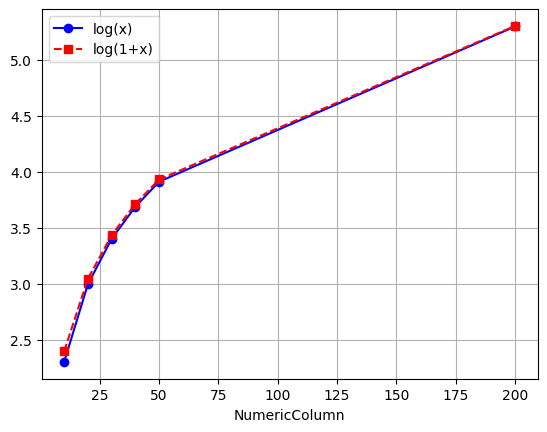

In [24]:
df["log"] = np.log(df["NumericColumn"])
df["log1p"] = np.log1p(df["NumericColumn"])

plt.plot(df["NumericColumn"], df["log"], marker="o", label="log(x)", color="blue")
plt.plot(df["NumericColumn"], df["log1p"], marker="s", label="log(1+x)", color="red", linestyle="--")

# оформление
plt.xlabel("NumericColumn")
plt.legend()
plt.grid(True)
plt.show()

,NumericColumn,z_scores,log,log1p
0,10,-0.747532,2.302585,2.397895
1,20,-0.592870,2.995732,3.044522
2,30,-0.438208,3.401197,3.433987
3,40,-0.283547,3.688879,3.713572
4,50,-0.128885,3.912023,3.931826
5,200,2.191042,5.298317,5.303305


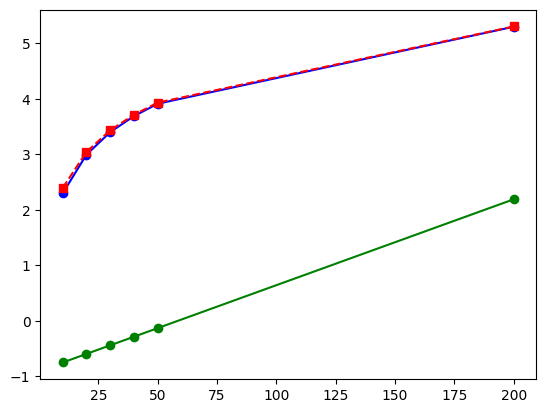

In [34]:
display(df)
plt.plot(df["NumericColumn"], df["log"], marker="o", label="log(x)", color="blue")
plt.plot(df["NumericColumn"], df["log1p"], marker="s", label="log(1+x)", color="red", linestyle="--")
plt.plot(df["NumericColumn"], df["z_scores"], marker="o", label="z-scores", color="green")

### <font color='coral'>4. Работа с категориальными данными. Кодирование меток</font>

Категориальные данные представляют собой дискретные значения, которые принадлежат к определенной категории или классу, и могут не иметь числового значения.

##### <font color='coral'>4.1. Использование библиотеки pandas</font>

###### <font color='coral'>4.1.1. Кодирование категориальных данных</font>

<b> Синтаксис:</b> encoded_data = pd.get_dummies(data, columns = ['categorical_column'])<br>

Параметры:
- data - DataFrame, содержащий категориальный(ые) столбец(ы), подлежащий(ие) кодированию.
- columns - список имен столбцов для кодирования.

In [25]:
# Создаем DataFrame с категориальными данными
import pandas as pd
data = pd.DataFrame({'Category': ['A', 'B', 'A', 'C', 'B']})
data

,Category
0,A
1,B
2,A
3,C
4,B


In [26]:
# Кодируем категориальные данные
encoded_data = pd.get_dummies(data, columns=['Category'])
encoded_data

,Category_A,Category_B,Category_C
0,True,False,False
1,False,True,False
2,True,False,False
3,False,False,True
4,False,True,False


###### <font color='coral'>4.1.2. Кодировка лейблов</font>

<b> Синтаксис:</b> data['encoded_column'] = pd.factorize(data['categorical_column'])[0]<br>

Параметры:
- categorical_column - имя или индекс категориального столбца для кодирования.

In [27]:
pd.factorize(data['Category'])

(array([0, 1, 0, 2, 1]), Index(['A', 'B', 'C'], dtype='object'))

In [28]:
data['Encoded_Category'] = pd.factorize(data['Category'])[0]
data

,Category,Encoded_Category
0,A,0
1,B,1
2,A,0
3,C,2
4,B,1


##### <font color='coral'>4.2. Использование библиотеки scikit-learn</font>

###### <font color='coral'>4.2.1. Ординальное кодирование</font>

In [29]:
from sklearn.preprocessing import OrdinalEncoder

# Инициализация объекта OrdinalEncoder
encoder = OrdinalEncoder()

# Подгонка и преобразование категориальных данных
data['Encoded_category'] = encoder.fit_transform(data[['Category']])
data

,Category,Encoded_Category,Encoded_category
0,A,0,0.0
1,B,1,1.0
2,A,0,0.0
3,C,2,2.0
4,B,1,1.0


###### <font color='coral'>4.2.2. One Hot кодирование</font>

In [38]:
from sklearn.preprocessing import OneHotEncoder
# Инициализация объекта OneHotEncoder
encoder = OneHotEncoder()
encoded_array = encoder.fit_transform(data[['Category']]).toarray()
encoded_array

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [31]:
# создаём DataFrame с бинарными колонками
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['Category']), index=data.index)
# объединяем с исходным DataFrame
data = pd.concat([data, encoded_df], axis=1)
data

,Category,Encoded_Category,Encoded_category,Category_A,Category_B,Category_C
0,A,0,0.0,1.0,0.0,0.0
1,B,1,1.0,0.0,1.0,0.0
2,A,0,0.0,1.0,0.0,0.0
3,C,2,2.0,0.0,0.0,1.0
4,B,1,1.0,0.0,1.0,0.0
